# Pipeline assembly

In [127]:
import numpy as np
import pandas as pd

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing \
  import FunctionTransformer, OrdinalEncoder, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: '{:.0f}'.format(x) if int(x) == x else '{:.3f}'.format(x))

In [2]:
# Get Ames housing data
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

In [6]:
# Feature columns
features = ['BedroomAbvGr', 'CentralAir', 'GarageCond', 'LotArea',
            'MSSubClass', 'Neighborhood', 'OverallQual', 'TotRmsAbvGrd',
            'YearBuilt', 'YearRemodAdd']

In [7]:
X = df[features]
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (876, 10) | Val: (292, 10) | Test: (292, 10)


In [30]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   BedroomAbvGr  1460 non-null   int64 
 1   CentralAir    1460 non-null   object
 2   GarageCond    1379 non-null   object
 3   LotArea       1460 non-null   int64 
 4   MSSubClass    1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   OverallQual   1460 non-null   int64 
 7   TotRmsAbvGrd  1460 non-null   int64 
 8   YearBuilt     1460 non-null   int64 
 9   YearRemodAdd  1460 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 114.2+ KB


In [95]:
# Ordinal columns
ordinal_cols = ['CentralAir']
ordering = [['N', 'Y']]

# One-hot columns
onehot_cols = ['Neighborhood']

# Numeric columns
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()

# Map GarageCond to a true/false column via a lambda function
lambda_cols = ['GarageCond']

assert(len(ordinal_cols) + len(onehot_cols) + len(numeric_cols) \
       + len(lambda_cols) == len(features)), "ERROR"

In [129]:
# Create pipelines
# ---
# There are no null values, so need to impute, except for GarageCond, where we
# map null values to False
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('encoder', OrdinalEncoder(categories=ordering))
])
# n.b. There should be no unknown values, raise error if so

onehot_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

def has_garage(X):
  return X.notna().astype(int)

lambda_pipeline = FunctionTransformer(has_garage)

print("Subpipelines defined")

Subpipelines defined


In [130]:
# Assemble column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,  numeric_cols),
        ('ord', ordinal_pipeline,  ordinal_cols),
        ('ohe', onehot_pipeline,   onehot_cols),
        ('lam', lambda_pipeline,   lambda_cols),
    ],
    remainder='drop'
)

print('ColumnTransformer assembled')

ColumnTransformer assembled


In [131]:
from sklearn import set_config

set_config(display='diagram')
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['BedroomAbvGr', 'LotArea', 'MSSubClass',
                                  'OverallQual', 'TotRmsAbvGrd', 'YearBuilt',
                                  'YearRemodAdd']),
                                ('ord',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['N',
                                                                              'Y']]))]),
                                 ['CentralAir']),
                                ('ohe',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Neighborhood']),
                                ('lam',
                                 FunctionTransformer(func=<function has_garage at 0x7ce1944a0fe0>),
                                 ['GarageCond'])])

In [132]:
# Fit preprocessor alone to inspect output shape and feature names
from sklearn.base import clone

preprocessor_check = clone(preprocessor)
preprocessor_check.fit(X_train)
n_features_out = preprocessor_check.transform(X_train[:1]).shape[1]
print(f'Preprocessor output features: {n_features_out}')
print(f'  Numeric:  {len(numeric_cols)}')
print(f'  Ordinal:  {len(ordinal_cols)}')
print(f'  Lambda :  {len(lambda_cols)}')

ohc_enc = preprocessor_check.named_transformers_['ohe'].named_steps['encoder']
ohc_names = ohc_enc.get_feature_names_out(onehot_cols)
print(f'  One-hot: {len(ohc_names)}')
print(f"Total check: {len(numeric_cols) + len(ordinal_cols)} + "
      f"{len(lambda_cols) + len(ohc_names)} == {n_features_out}")

Preprocessor output features: 34
  Numeric:  7
  Ordinal:  1
  Lambda :  1
  One-hot: 25
Total check: 8 + 26 == 34


In [133]:
preprocessor_check.feature_names_in_

array(['BedroomAbvGr', 'CentralAir', 'GarageCond', 'LotArea',
       'MSSubClass', 'Neighborhood', 'OverallQual', 'TotRmsAbvGrd',
       'YearBuilt', 'YearRemodAdd'], dtype=object)

# Model training

## Linear Regression

In [108]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

lr_val_pred = lr_pipeline.predict(X_val)
lr_mae  = mean_absolute_error(y_val, lr_val_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_r2   = r2_score(y_val, lr_val_pred)

print(f'Linear Regression -- Val MAE: {lr_mae:.0f} | RMSE: {lr_rmse:.0f} | R2: {lr_r2:.3f}')

Linear Regression -- Val MAE: 26394 | RMSE: 45714 | R2: 0.778


In [109]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                            cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse = -cv_scores
print(f'Linear Regression -- 5-Fold CV RMSE: {cv_rmse.mean():.0f} ± {cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in cv_rmse]}')

Linear Regression -- 5-Fold CV RMSE: 36011 ± 5666
Individual folds: ['36130', '46736', '31589', '34431', '31170']


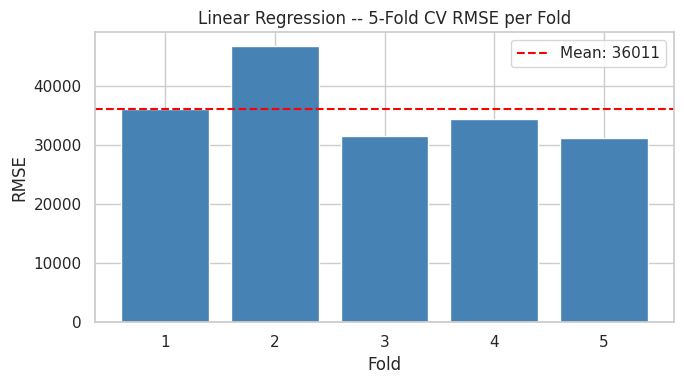

In [110]:
# Bar chart of CV fold scores
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_rmse, color='steelblue')
plt.axhline(cv_rmse.mean(), color='red', linestyle='--', label=f'Mean: {cv_rmse.mean():.0f}')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Linear Regression -- 5-Fold CV RMSE per Fold')
plt.legend()
plt.tight_layout()
plt.show()

## Random Forest

In [134]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

rf_val_pred = rf_pipeline.predict(X_val)
rf_mae  = mean_absolute_error(y_val, rf_val_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_r2   = r2_score(y_val, rf_val_pred)

print(f'Random Forest    -- Val MAE: {rf_mae:.0f} | RMSE: {rf_rmse:.0f} | R2: {rf_r2:.3f}')

Random Forest    -- Val MAE: 25666 | RMSE: 40231 | R2: 0.828


In [135]:
rf_cv = cross_val_score(rf_pipeline, X_train, y_train,
                        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_cv_rmse = -rf_cv
print(f'Random Forest -- 5-Fold CV RMSE: {rf_cv_rmse.mean():.0f} ± {rf_cv_rmse.std():.0f}')
print(f'Individual folds: {[f"{v:.0f}" for v in rf_cv_rmse]}')

Random Forest -- 5-Fold CV RMSE: 35204 ± 4132
Individual folds: ['35732', '42841', '34209', '31856', '31384']


## Model comparison

In [124]:
comparison = pd.DataFrame([
    {'model': 'LinearRegression', 'val_mae': lr_mae, 'val_rmse': lr_rmse, 'val_r2': lr_r2},
    {'model': 'RandomForest',     'val_mae': rf_mae, 'val_rmse': rf_rmse, 'val_r2': rf_r2},
]).sort_values('val_rmse')
comparison

,model,val_mae,val_rmse,val_r2
1,RandomForest,25665.638,40230.773,0.828
0,LinearRegression,26393.602,45713.909,0.778


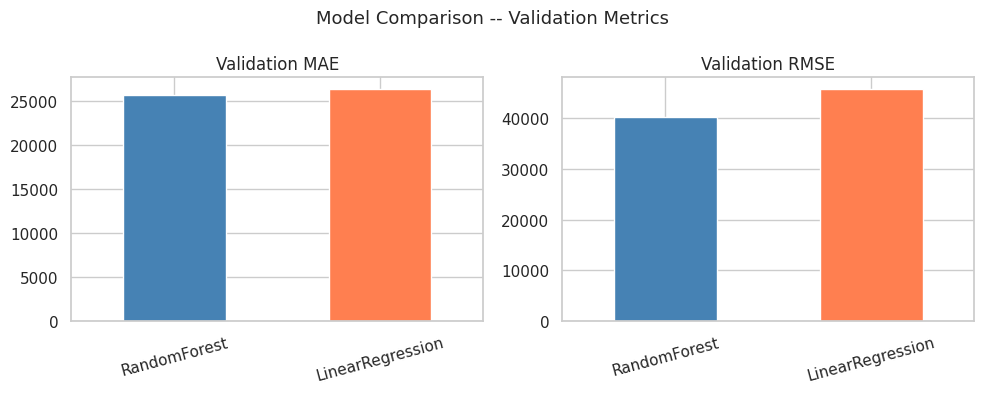

In [125]:
# Bar chart comparison of MAE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

comparison.plot(kind='bar', x='model', y='val_mae', ax=axes[0], legend=False, color=['steelblue', 'coral'])
axes[0].set_title('Validation MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

comparison.plot(kind='bar', x='model', y='val_rmse', ax=axes[1], legend=False, color=['steelblue', 'coral'])
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison -- Validation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

In [142]:
# Better model is Random Forest
best_model = rf_pipeline

joblib.dump(best_model, 'w2_real_estate_agent.joblib')

# Verify loaded model works on raw data
loaded_model = joblib.load('w2_real_estate_agent.joblib')
raw_sample = X_val.iloc[:5].copy()
preds = loaded_model.predict(raw_sample)
actuals = y_val.iloc[:5].values

print('Loaded pipeline predictions on 5 raw validation rows:')
for i, (pred, actual) in enumerate(zip(preds, actuals)):
    diff = pred - actual
    print(f"  Row {i}: predicted = ${pred:8,.0f}  "
          f"actual = ${actual:8,.0f}  diff = ${diff:+8,.0f}")

Loaded pipeline predictions on 5 raw validation rows:
  Row 0: predicted = $ 146,324  actual = $ 135,000  diff = $ +11,324
  Row 1: predicted = $ 396,656  actual = $ 501,837  diff = $-105,181
  Row 2: predicted = $ 333,179  actual = $ 305,000  diff = $ +28,179
  Row 3: predicted = $ 124,087  actual = $ 125,000  diff = $    -913
  Row 4: predicted = $ 391,635  actual = $ 556,581  diff = $-164,946


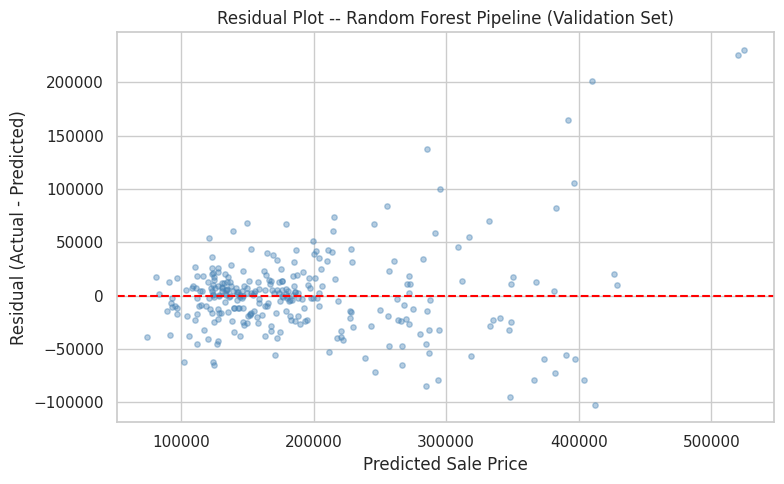

In [143]:
# Residual plot for best pipeline on validation set
residuals = y_val - rf_val_pred

plt.figure(figsize=(8, 5))
plt.scatter(rf_val_pred, residuals, alpha=0.4, s=15, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot -- Random Forest Pipeline (Validation Set)')
plt.tight_layout()
plt.show()

## Final test

In [144]:
# Evaluate model once on test set
loaded_model = joblib.load('w2_real_estate_agent.joblib')

preds = rf_pipeline.predict(X_test)
rf_mae  = mean_absolute_error(y_test, preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, preds))
rf_r2   = r2_score(y_test, preds)

print(f'Random Forest    -- Test MAE: {rf_mae:.0f} | RMSE: {rf_rmse:.0f} | R2: {rf_r2:.3f}')

Random Forest    -- Test MAE: 21982 | RMSE: 33344 | R2: 0.773


**Conclusion:** As we can see, the model isn't a great fit on the test set, as R2 went down from 0.828 to 0.773.